# Figures for Slides
### SIAM Life Sciences 2026 — Deep Learning Section

**Contents:**
1. Activation functions: ReLU and Sigmoid
2. Two inputs, one output: Sigmoid as a surface
3. Composition: Two neurons in sequence
4. ReLU vs Softplus
5. MLP architecture diagram
6. CNN architecture diagram


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ── Global style ─────────────────────────────────────────────────────────────
mpl.rcParams.update({
    'font.family'      : 'sans-serif',
    'font.sans-serif'  : ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size'        : 16,
    'axes.titlesize'   : 20,
    'axes.labelsize'   : 18,
    'xtick.labelsize'  : 14,
    'ytick.labelsize'  : 14,
    'legend.fontsize'  : 15,
    'figure.dpi'       : 150,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.linewidth'   : 1.4,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2,
    'xtick.direction'  : 'out',
    'ytick.direction'  : 'out',
    'grid.alpha'       : 0.35,
    'grid.linestyle'   : '--',
    'grid.linewidth'   : 0.8,
})

print('Style loaded.')

Style loaded.


---
## 1. Activation Functions: ReLU and Sigmoid

$$\text{ReLU}(x) = \max(0, x) \qquad \sigma(x) = \frac{1}{1 + e^{-x}}$$

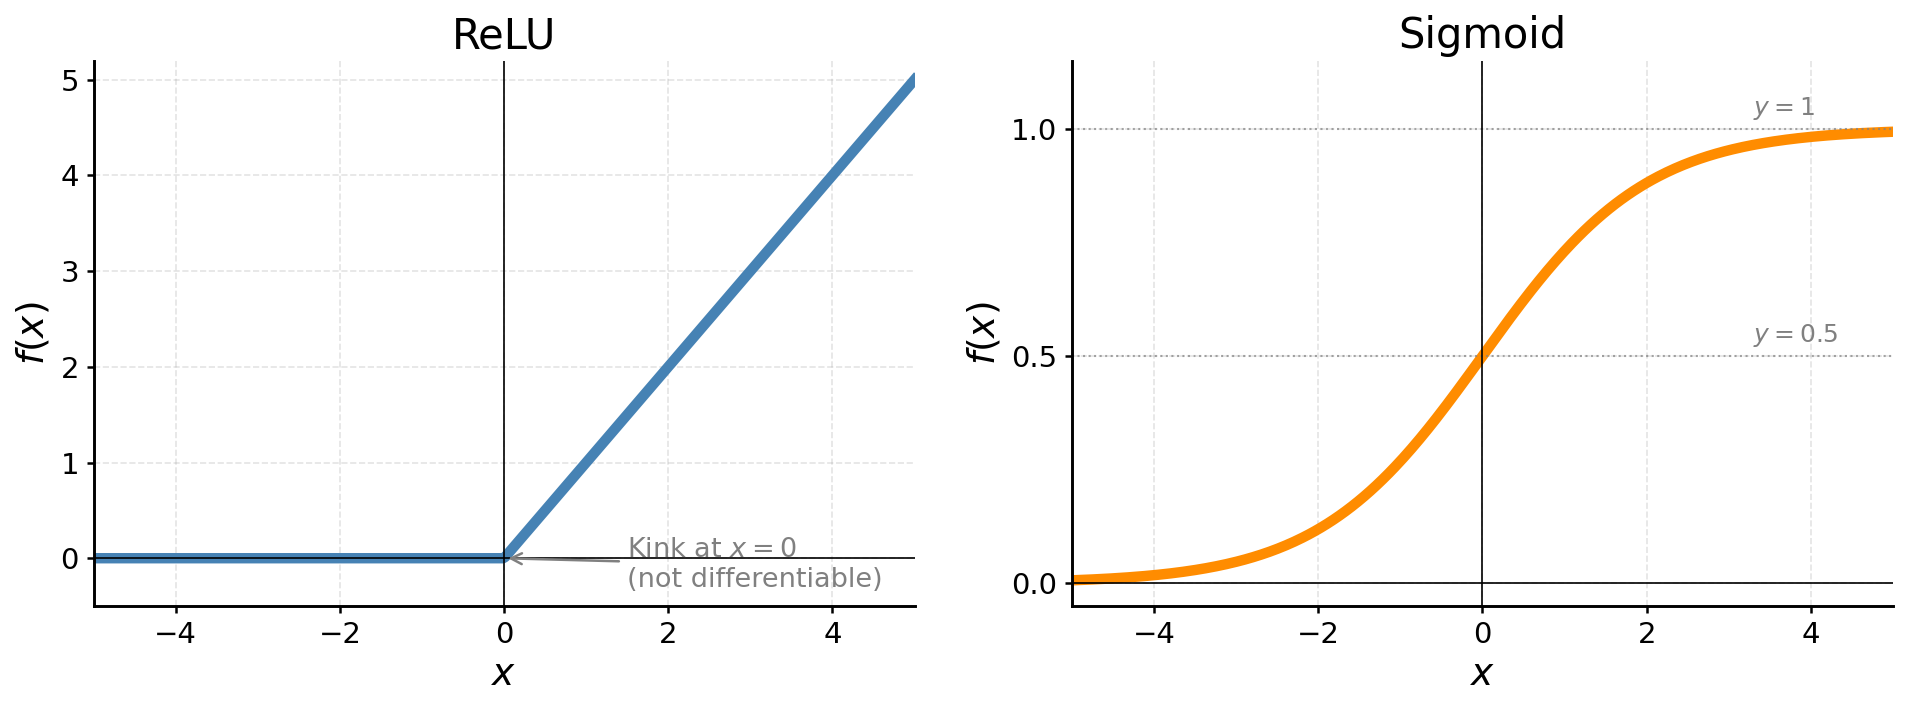

Saved: activation_functions.png


In [2]:
x = np.linspace(-5, 5, 400)
relu    = np.maximum(0, x)
sigmoid = 1 / (1 + np.exp(-x))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── ReLU ─────────────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(x, relu, color='steelblue', lw=5)
ax.axhline(0, color='black', lw=0.8, ls='-')
ax.axvline(0, color='black', lw=0.8, ls='-')
ax.set_xlabel('$x$')
ax.set_ylabel('$f(x)$')
ax.set_title('ReLU')
ax.set_xlim(-5, 5)
ax.set_ylim(-0.5, 5.2)
ax.grid(True)
# Annotate the kink
ax.annotate('Kink at $x=0$\n(not differentiable)',
            xy=(0, 0), xytext=(1.5, -0.3),
            fontsize=13, color='gray',
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.2))

# ── Sigmoid ───────────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(x, sigmoid, color='darkorange', lw=5)
ax.axhline(0,   color='black', lw=0.8, ls='-')
ax.axhline(1,   color='gray',  lw=1.0, ls=':', alpha=0.7)
ax.axhline(0.5, color='gray',  lw=1.0, ls=':', alpha=0.7)
ax.axvline(0,   color='black', lw=0.8, ls='-')
ax.set_xlabel('$x$')
ax.set_ylabel('$f(x)$')
ax.set_title('Sigmoid')
ax.set_xlim(-5, 5)
ax.set_ylim(-0.05, 1.15)
ax.set_yticks([0, 0.5, 1.0])
ax.grid(True)
# Annotate asymptotes
ax.text(3.3, 1.03, '$y = 1$', fontsize=12, color='gray')
ax.text(3.3, 0.53, '$y = 0.5$', fontsize=12, color='gray')

#plt.suptitle('Activation Functions', fontsize=22, y=1.02)
plt.tight_layout()
plt.savefig('activation_functions.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: activation_functions.png')

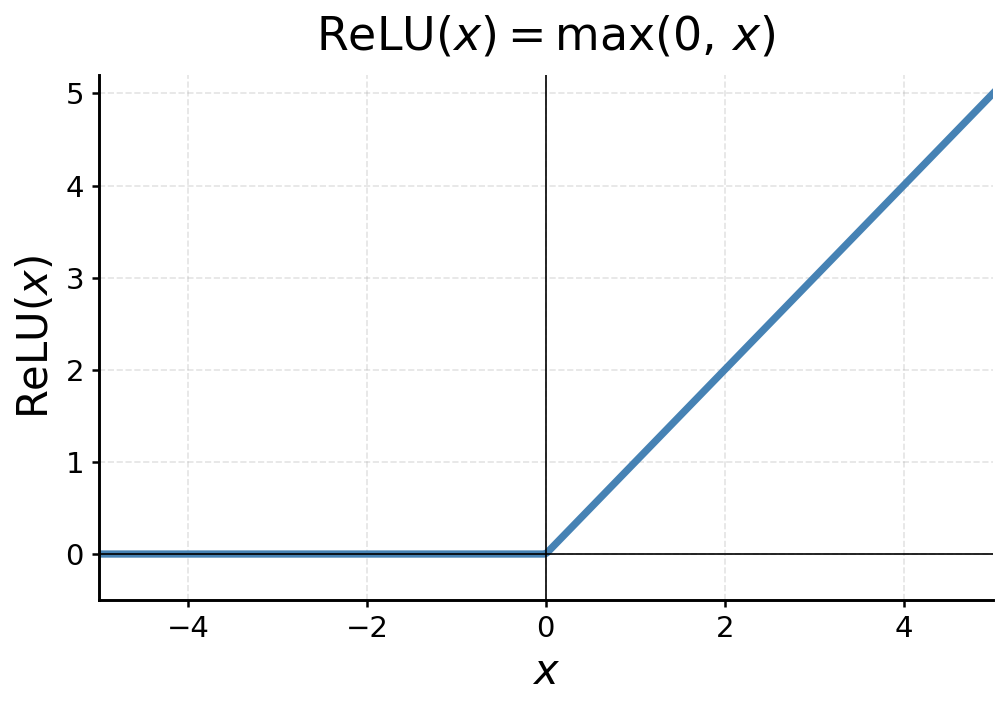

Saved: relu.png


In [3]:
# ── Individual ReLU figure (for slides where you show one at a time) ──────────
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(x, relu, color='steelblue', lw=3.5)
ax.axhline(0, color='black', lw=0.8)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('$x$', fontsize=20)
ax.set_ylabel('$\\mathrm{ReLU}(x)$', fontsize=20)
ax.set_title('$\\mathrm{ReLU}(x) = \\max(0,\, x)$', fontsize=22, pad=12)
ax.set_xlim(-5, 5)
ax.set_ylim(-0.5, 5.2)
ax.grid(True)
plt.tight_layout()
plt.savefig('relu.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: relu.png')

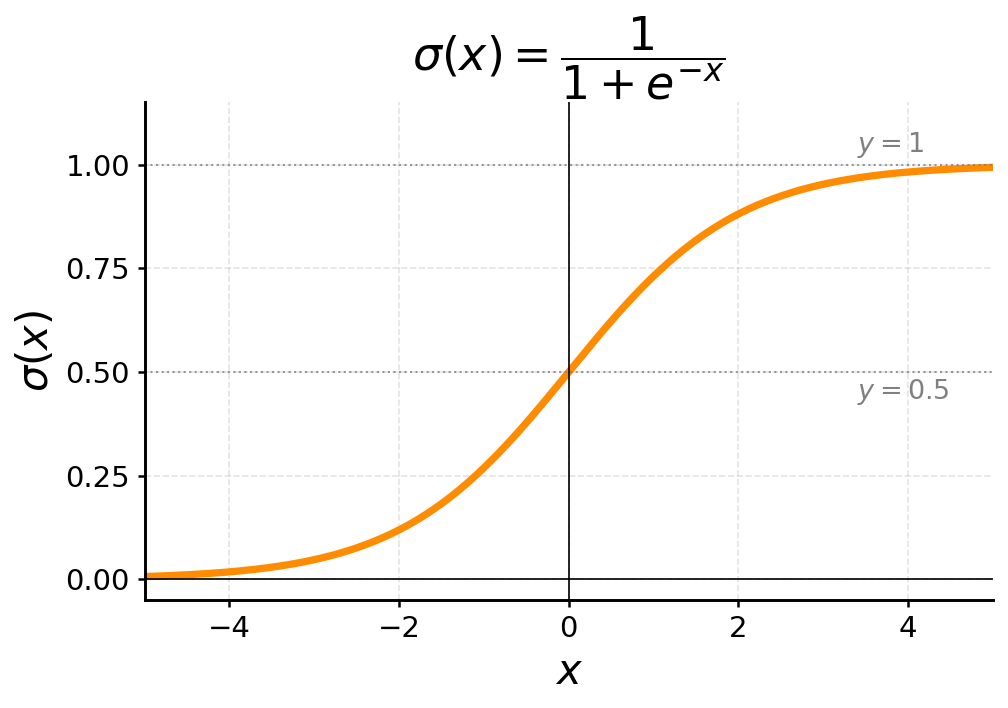

Saved: sigmoid.png


In [4]:
# ── Individual Sigmoid figure ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(x, sigmoid, color='darkorange', lw=3.5)
ax.axhline(0,   color='black', lw=0.8)
ax.axhline(1,   color='gray',  lw=1.0, ls=':', alpha=0.8)
ax.axhline(0.5, color='gray',  lw=1.0, ls=':', alpha=0.8)
ax.axvline(0,   color='black', lw=0.8)
ax.set_xlabel('$x$', fontsize=20)
ax.set_ylabel('$\\sigma(x)$', fontsize=20)
ax.set_title(r'$\sigma(x) = \dfrac{1}{1+e^{-x}}$', fontsize=22, pad=12)
ax.set_xlim(-5, 5)
ax.set_ylim(-0.05, 1.15)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.text(3.4, 1.03,  '$y = 1$',   fontsize=13, color='gray')
ax.text(3.4, 0.435, '$y = 0.5$', fontsize=13, color='gray')
ax.grid(True)
plt.tight_layout()
plt.savefig('sigmoid.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: sigmoid.png')

---
## 2. Two Inputs, One Output: Sigmoid as a Surface

With inputs $x_1, x_2 \in \mathbb{R}$ and a single neuron:

$$a = \sigma(w_1 x_1 + w_2 x_2 + b), \qquad a \in [0, 1]$$

The pre-activation $z = w_1 x_1 + w_2 x_2 + b$ is a tilted plane.  
Sigmoid squashes it into a smooth ramp from 0 to 1.  
The **decision boundary** (where $a = 0.5$) is the line $w_1 x_1 + w_2 x_2 + b = 0$.

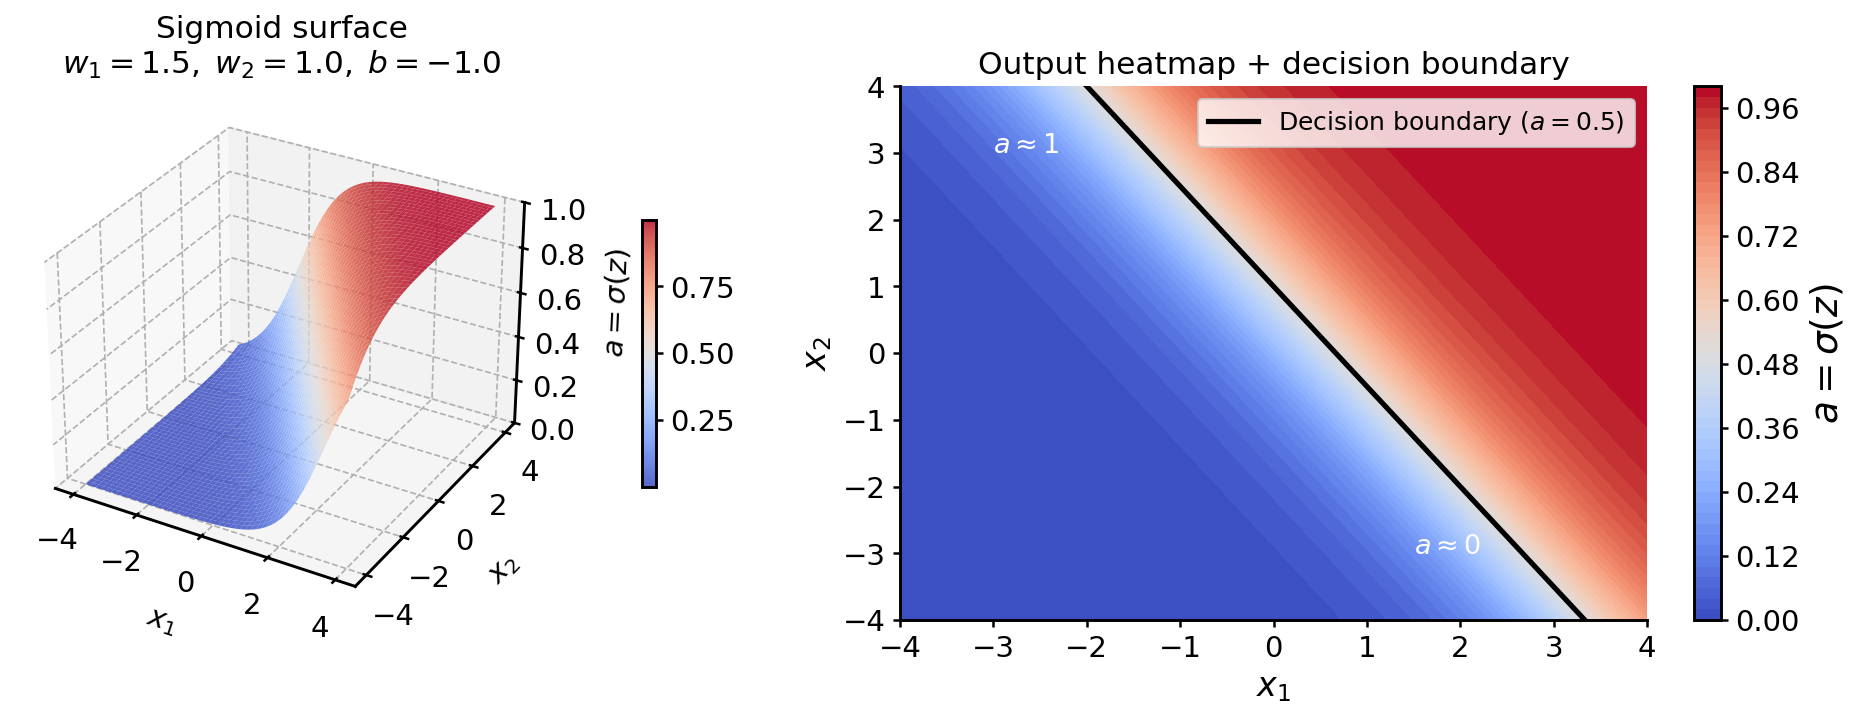

Decision boundary: 1.5*x1 + 1.0*x2 + -1.0 = 0
Saved: sigmoid_2d_surface.png


In [5]:
from mpl_toolkits.mplot3d import Axes3D  # noqa

# ── Parameters — try changing these to see the effect ────────────────────────
w1 = 1.5    # weight on x1  (rotates boundary)
w2 = 1.0    # weight on x2  (rotates boundary)
b  = -1.0   # bias           (shifts boundary)

# ── Grid ─────────────────────────────────────────────────────────────────────
x1 = np.linspace(-4, 4, 200)
x2 = np.linspace(-4, 4, 200)
X1, X2 = np.meshgrid(x1, x2)

Z = w1*X1 + w2*X2 + b          # pre-activation (tilted plane)
A = 1 / (1 + np.exp(-Z))       # sigmoid output (smooth ramp)

# Decision boundary: w1*x1 + w2*x2 + b = 0  →  x2 = -(w1*x1 + b)/w2
x1_db = np.linspace(-4, 4, 100)
x2_db = -(w1*x1_db + b) / w2

fig = plt.figure(figsize=(14, 5))

# ── 3D surface ────────────────────────────────────────────────────────────────
ax3d = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax3d.plot_surface(X1, X2, A, cmap='coolwarm', alpha=0.85,
                         linewidth=0, antialiased=True)
ax3d.set_xlabel('$x_1$', fontsize=14, labelpad=8)
ax3d.set_ylabel('$x_2$', fontsize=14, labelpad=8)
ax3d.set_zlabel('$a = \sigma(z)$', fontsize=14, labelpad=8)
ax3d.set_title(f'Sigmoid surface\n$w_1={w1},\; w_2={w2},\; b={b}$', fontsize=15)
ax3d.set_zlim(0, 1)
fig.colorbar(surf, ax=ax3d, shrink=0.5, pad=0.1)

# ── 2D heatmap + decision boundary ───────────────────────────────────────────
ax2d = fig.add_subplot(1, 2, 2)
hm = ax2d.contourf(X1, X2, A, levels=50, cmap='coolwarm', vmin=0, vmax=1)
fig.colorbar(hm, ax=ax2d, label='$a = \sigma(z)$')

# Decision boundary
ax2d.plot(x1_db, x2_db, 'k-', lw=2.5, label='Decision boundary ($a = 0.5$)')
ax2d.set_xlim(-4, 4); ax2d.set_ylim(-4, 4)
ax2d.set_xlabel('$x_1$', fontsize=16)
ax2d.set_ylabel('$x_2$', fontsize=16)
ax2d.set_title('Output heatmap + decision boundary', fontsize=15)
ax2d.legend(fontsize=12, loc='upper right')

# Annotate regions
ax2d.text(-3, 3,  '$a \\approx 1$', fontsize=13, color='white', fontweight='bold')
ax2d.text( 1.5, -3, '$a \\approx 0$', fontsize=13, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('sigmoid_2d_surface.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Decision boundary: {w1}*x1 + {w2}*x2 + {b} = 0')
print('Saved: sigmoid_2d_surface.png')

---
## 3. Composition: Two Neurons in Sequence

$$a^{(1)} = f\!\left(w^{(1)} x + b^{(1)}\right)$$
$$a^{(2)} = f\!\left(w^{(2)} a^{(1)} + b^{(2)}\right) = f\!\left(w^{(2)} f\!\left(w^{(1)} x + b^{(1)}\right) + b^{(2)}\right)$$

Even with just 2 neurons there is no clean closed form — $f$ is composed with itself.

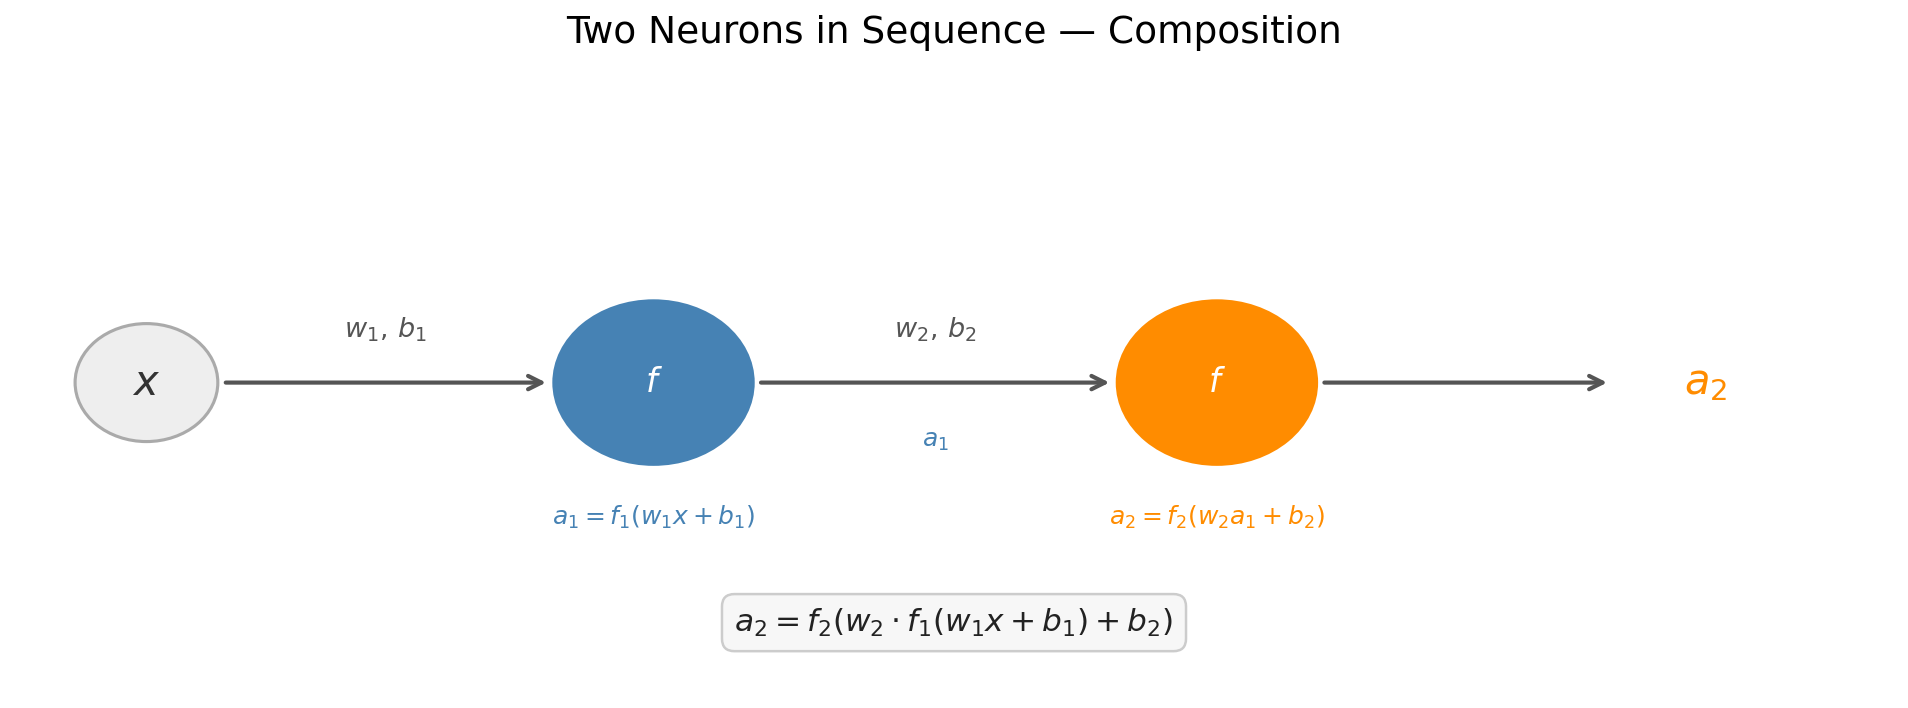

Saved: two_neurons_composition.png


In [6]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(13, 5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 4)
ax.axis('off')

def neuron(ax, cx, cy, radius=0.55, color='steelblue'):
    circ = plt.Circle((cx, cy), radius, color=color, zorder=3, ec='white', lw=2)
    ax.add_patch(circ)
    ax.text(cx, cy, '$f$', ha='center', va='center',
            fontsize=16, color='white', fontweight='bold', zorder=4)

def arrow(ax, x1, y1, x2, y2, label='', color='#555555'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=2.0))
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2 + 0.25
        ax.text(mx, my, label, ha='center', va='bottom', fontsize=13, color=color)

cy = 2.0

# Input
ax.add_patch(plt.Circle((0.7, cy), 0.38, color='#eeeeee', ec='#aaaaaa', lw=1.5, zorder=2))
ax.text(0.7, cy, '$x$', ha='center', va='center', fontsize=20, color='#333333', zorder=3)

# x -> neuron 1
arrow(ax, 1.1, cy, 2.85, cy, label='$w_1,\, b_1$')

# Neuron 1
neuron(ax, 3.4, cy, color='steelblue')
ax.text(3.4, cy - 0.78, '$a_1 = f_1(w_1 x + b_1)$',
        ha='center', va='top', fontsize=12, color='steelblue')

# neuron 1 -> neuron 2
arrow(ax, 3.95, cy, 5.85, cy, label='$w_2,\, b_2$')
ax.text(4.9, cy - 0.3, '$a_1$', ha='center', va='top', fontsize=12, color='steelblue')

# Neuron 2
neuron(ax, 6.4, cy, color='darkorange')
ax.text(6.4, cy - 0.78, '$a_2 = f_2(w_2 a_1 + b_2)$',
        ha='center', va='top', fontsize=12, color='darkorange')

# neuron 2 -> output
arrow(ax, 6.95, cy, 8.5, cy)
ax.text(9.0, cy, '$a_2$', ha='center', va='center', fontsize=20, color='darkorange')

# Composition formula at bottom
formula = '$a_2 = f_2(w_2 \cdot f_1(w_1 x + b_1) + b_2)$'
ax.text(5.0, 0.35, formula, ha='center', va='bottom', fontsize=15, color='#222222',
        bbox=dict(boxstyle='round,pad=0.4', fc='#f7f7f7', ec='#cccccc', lw=1.2))

ax.set_title('Two Neurons in Sequence — Composition', fontsize=18, pad=14)
plt.tight_layout()
plt.savefig('two_neurons_composition.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: two_neurons_composition.png')


---
## 4. ReLU vs Softplus

ReLU is not differentiable at $x=0$. Softplus is a smooth approximation:

$$\text{Softplus}(x) = \log(1 + e^x)$$

Its derivative is exactly the sigmoid: $\frac{d}{dx}\text{Softplus}(x) = \sigma(x)$.


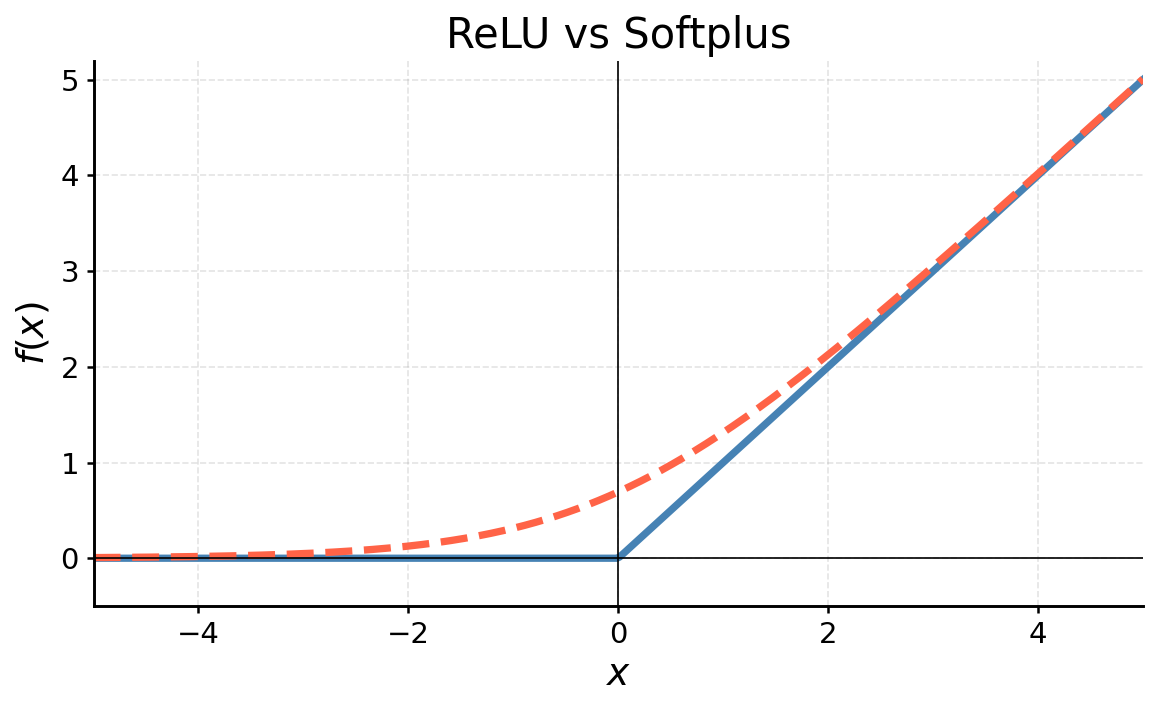

Saved: relu_vs_softplus.png


In [7]:
x = np.linspace(-5, 5, 400)
relu     = np.maximum(0, x)
softplus = np.log1p(np.exp(x))   # numerically stable: log(1 + e^x)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, relu,     color='steelblue',  lw=3.5)
ax.plot(x, softplus, color='tomato',     lw=3.5, linestyle='--')
ax.axhline(0, color='black', lw=0.8)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('$x$')
ax.set_ylabel('$f(x)$')
ax.set_title('ReLU vs Softplus', fontsize=20)
ax.set_xlim(-5, 5)
ax.set_ylim(-0.5, 5.2)
ax.grid(True)
plt.tight_layout()
plt.savefig('relu_vs_softplus.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: relu_vs_softplus.png')


---
## 5. MLP Architecture: 784 → 16 → 1

Input: 28×28 MNIST image, flattened to $\mathbf{x} \in \mathbb{R}^{784}$.  
Hidden layer: $\mathbf{h} = \text{ReLU}(W_1 \mathbf{x} + \mathbf{b}_1)$, $W_1 \in \mathbb{R}^{16 \times 784}$.  
Output: $\hat{y} = \sigma(\mathbf{w}_2^T \mathbf{h} + b_2) \in [0,1]$.


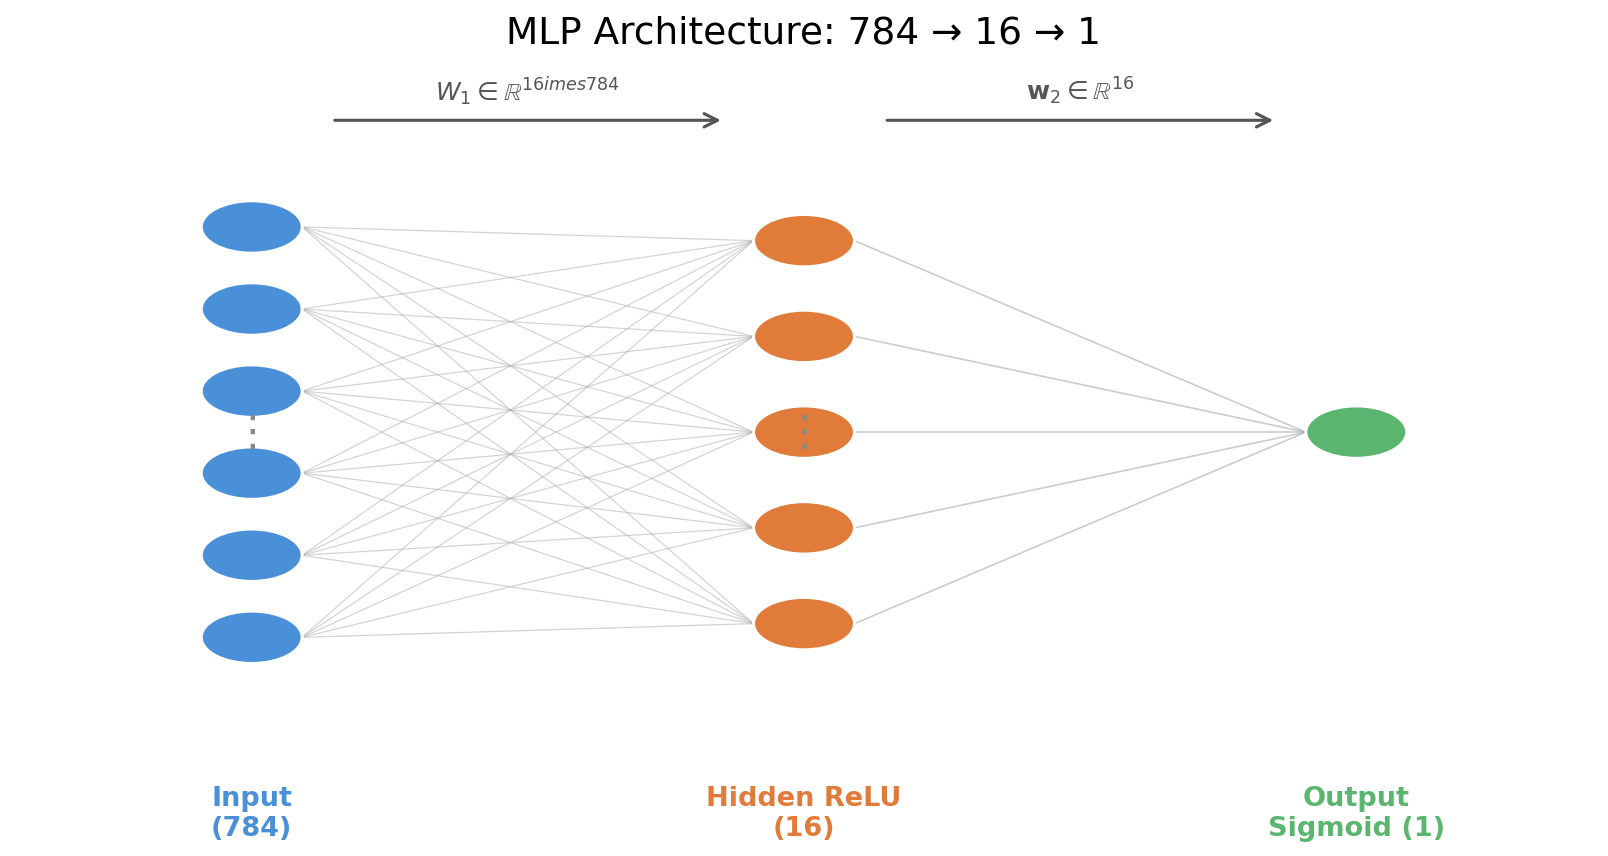

Saved: mlp_architecture.png


In [8]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.set_xlim(0, 10); ax.set_ylim(0, 9); ax.axis('off')

# ── Layer positions ────────────────────────────────────────────────────────────
layer_x   = [1.5, 5.0, 8.5]
layer_n   = [6, 5, 1]          # nodes to DRAW (not actual count)
layer_lbl = ['Input\n(784)', 'Hidden ReLU\n(16)', 'Output\nSigmoid (1)']
layer_col = ['#4a90d9', '#e07b39', '#5ab56e']
dot_layers = [True, True, False]   # show ellipsis?

node_y = {}
for li, (lx, nn, col, dots) in enumerate(zip(layer_x, layer_n, layer_col, dot_layers)):
    ys = []
    spacing = 7.0 / (nn + 1)
    for ni in range(nn):
        y = 1.0 + spacing * (ni + 1)
        circ = plt.Circle((lx, y), 0.32, color=col, ec='white', lw=1.5, zorder=3)
        ax.add_patch(circ)
        ys.append(y)
    if dots:
        # ellipsis between top 3 and bottom 3
        mid_y = 4.5
        ax.text(lx, mid_y, '⋮', ha='center', va='center', fontsize=20, color='#888')
    node_y[li] = ys

# ── Connections ────────────────────────────────────────────────────────────────
for y1 in node_y[0]:
    for y2 in node_y[1]:
        ax.plot([layer_x[0]+0.32, layer_x[1]-0.32], [y1, y2],
                color='#aaaaaa', lw=0.6, alpha=0.5, zorder=1)
for y1 in node_y[1]:
    for y2 in node_y[2]:
        ax.plot([layer_x[1]+0.32, layer_x[2]-0.32], [y1, y2],
                color='#aaaaaa', lw=0.8, alpha=0.6, zorder=1)

# ── Layer labels ───────────────────────────────────────────────────────────────
for lx, lbl, col in zip(layer_x, layer_lbl, layer_col):
    ax.text(lx, 0.2, lbl, ha='center', va='top', fontsize=13,
            color=col, fontweight='bold')

# ── Dimension annotations ──────────────────────────────────────────────────────
ax.annotate('', xy=(layer_x[1]-0.5, 8.3), xytext=(layer_x[0]+0.5, 8.3),
            arrowprops=dict(arrowstyle='->', color='#555', lw=1.5))
ax.text(3.25, 8.55, '$W_1 \in \mathbb{R}^{16 \times 784}$',
        ha='center', fontsize=12, color='#555')

ax.annotate('', xy=(layer_x[2]-0.5, 8.3), xytext=(layer_x[1]+0.5, 8.3),
            arrowprops=dict(arrowstyle='->', color='#555', lw=1.5))
ax.text(6.75, 8.55, '$\mathbf{w}_2 \in \mathbb{R}^{16}$',
        ha='center', fontsize=12, color='#555')

ax.set_title('MLP Architecture: 784 → 16 → 1', fontsize=18, pad=10)
plt.tight_layout()
plt.savefig('mlp_architecture.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: mlp_architecture.png')


---
## 6. CNN Architecture

Input: 28×28×1 → Conv(16) → Pool → Conv(32) → Pool → Flatten(1568) → Dense(16) → Dense(1)


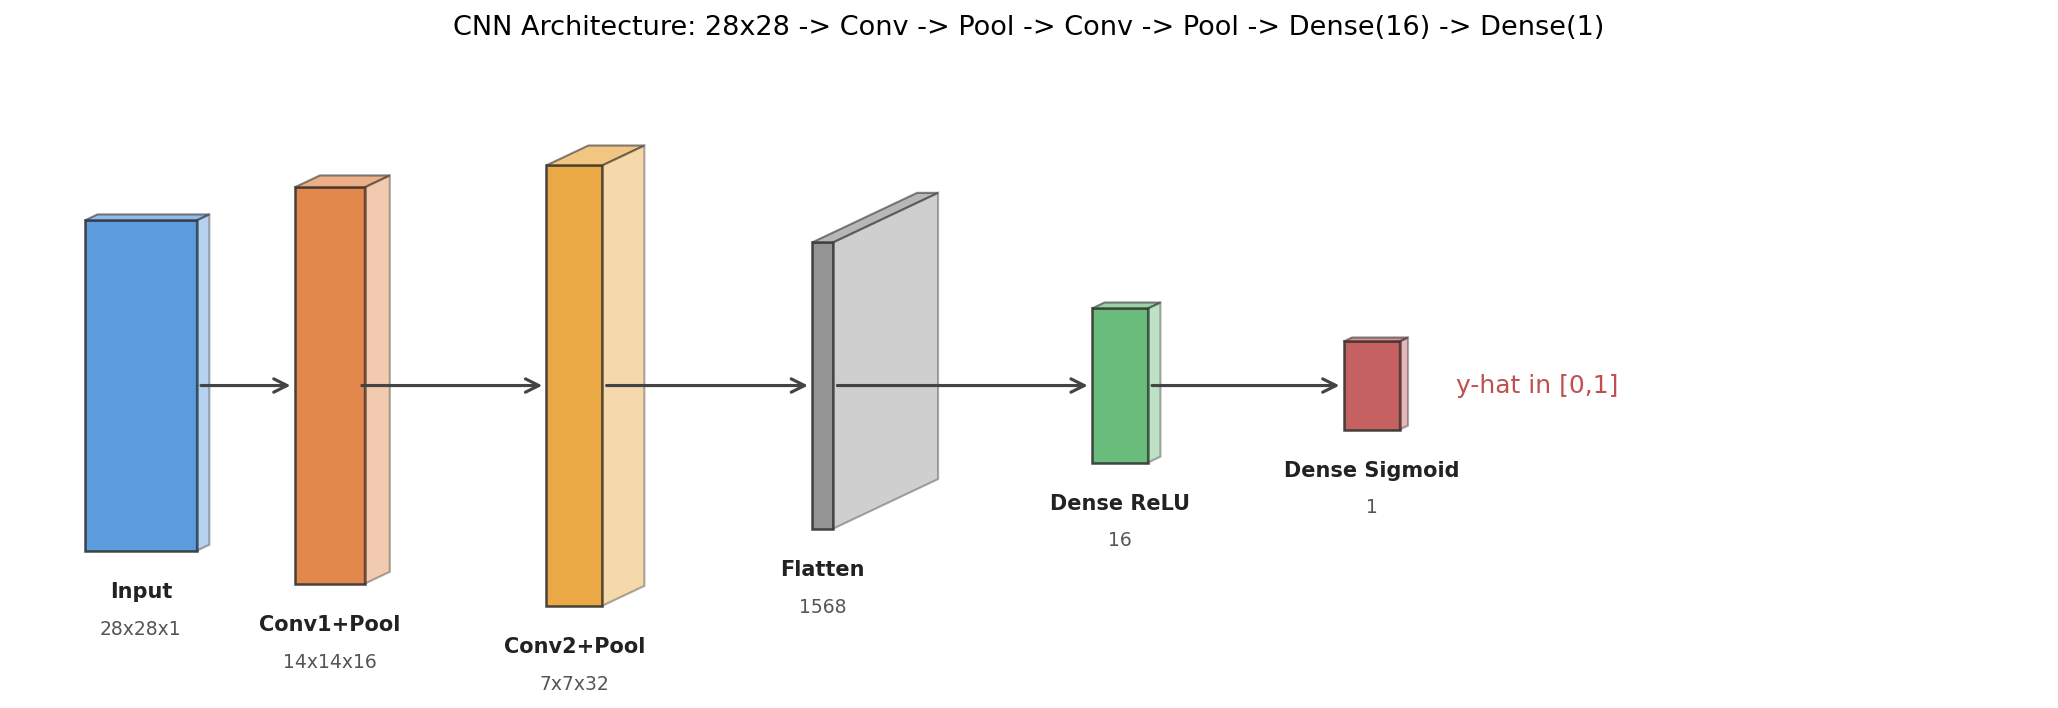

Saved: cnn_architecture.png


In [9]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.set_xlim(-0.5, 14); ax.set_ylim(0, 5.5); ax.axis('off')

def draw_box(ax, x, y, w, h, d, face_col, label='', sublabel=''):
    offset = d * 0.3
    front = plt.Polygon([[x,y],[x+w,y],[x+w,y+h],[x,y+h]],
                         fc=face_col, ec='#333', lw=1.2, zorder=2, alpha=0.9)
    top   = plt.Polygon([[x,y+h],[x+w,y+h],[x+w+offset,y+h+offset*0.6],[x+offset,y+h+offset*0.6]],
                         fc=face_col, ec='#333', lw=1.0, alpha=0.6, zorder=2)
    right = plt.Polygon([[x+w,y],[x+w+offset,y+offset*0.6],[x+w+offset,y+h+offset*0.6],[x+w,y+h]],
                         fc=face_col, ec='#333', lw=1.0, alpha=0.4, zorder=2)
    for p in [front, top, right]:
        ax.add_patch(p)
    if label:
        ax.text(x + w/2, y - 0.28, label, ha='center', va='top',
                fontsize=10, fontweight='bold', color='#222')
    if sublabel:
        ax.text(x + w/2, y - 0.62, sublabel, ha='center', va='top',
                fontsize=9, color='#555')

# x, y, w, h, depth, color, label, sublabel
specs = [
    (0.0,  1.0, 0.8, 3.0, 0.3, '#4a90d9', 'Input',        '28x28x1'),
    (1.5,  0.7, 0.5, 3.6, 0.6, '#e07b39', 'Conv1+Pool',   '14x14x16'),
    (3.3,  0.5, 0.4, 4.0, 1.0, '#e8a030', 'Conv2+Pool',   '7x7x32'),
    (5.2,  1.2, 0.15,2.6, 2.5, '#888888', 'Flatten',      '1568'),
    (7.2,  1.8, 0.4, 1.4, 0.3, '#5ab56e', 'Dense ReLU',   '16'),
    (9.0,  2.1, 0.4, 0.8, 0.2, '#c05050', 'Dense Sigmoid','1'),
]
for spec in specs:
    draw_box(ax, *spec)

# Arrows
for x1, x2, y in [(0.8,1.5,2.5),(1.95,3.3,2.5),(3.7,5.2,2.5),(5.35,7.2,2.5),(7.6,9.0,2.5)]:
    ax.annotate('', xy=(x2, y), xytext=(x1, y),
                arrowprops=dict(arrowstyle='->', color='#444', lw=1.5))

ax.text(9.8, 2.5, 'y-hat in [0,1]', ha='left', va='center', fontsize=12, color='#c05050')
ax.set_title('CNN Architecture: 28x28 -> Conv -> Pool -> Conv -> Pool -> Dense(16) -> Dense(1)',
             fontsize=13, pad=10)
plt.tight_layout()
plt.savefig('cnn_architecture.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: cnn_architecture.png')
